# Global monthly temperature anomaly data

The dataset contains the surface Earth temperature anomaly* data from 1880 to 2019. The data is from the NASA GISS Surface Temperature Analysis (GISTEMP). The data is in the form of a CSV file.

*a change in temperature relative to a reference period (average temperature of 1951-1980)

Source: https://data.giss.nasa.gov/gistemp/

## I want:
monthly temperature anomaly for each year in the form of 
- a line chart (simple averages)
- a box plot (distribution of temperature anomaly)

<!-- insert images -->
<img src="images/part2/simple-line-yearly.png" width="400"/>
<img src="images/part2/boxplot.png" width="500"/>

In [1]:
import pathlib


ROOT = pathlib.Path()
DATASETS = ROOT / 'datasets'

MONTHS = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
GLOBAL_TEMPERATURE_ANOMALY_CSV = DATASETS / 'global-monthly-temperature-anomaly.csv'

In [4]:
import pandas as pd

df = pd.read_csv(GLOBAL_TEMPERATURE_ANOMALY_CSV)[['Year'] + MONTHS]

<Axes: title={'center': 'Global Monthly Temperature Anomaly (°C)'}, xlabel='Year', ylabel='Temperature Anomaly (°C)'>

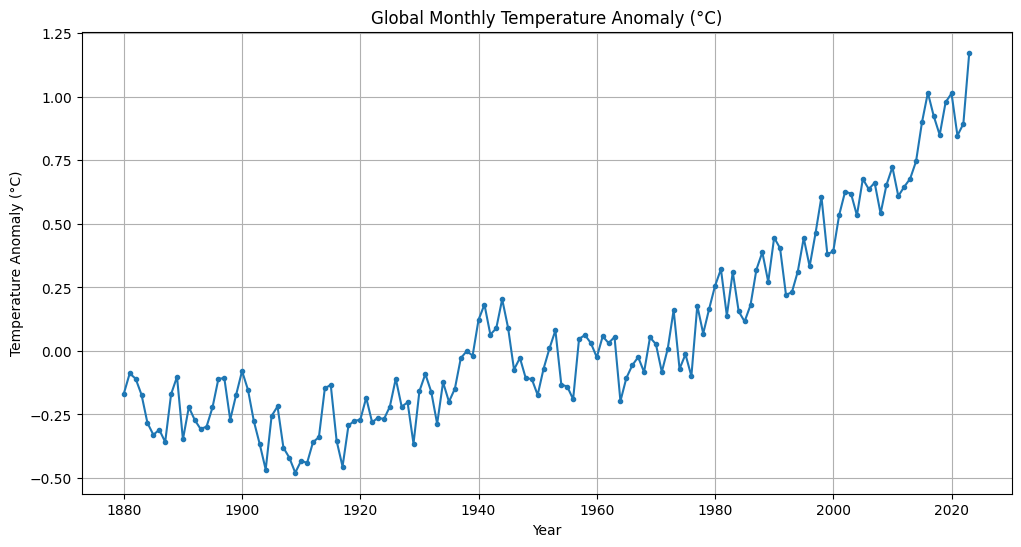

In [56]:
(
    df
    .iloc[:-1, :]
    .astype(float)
    .set_index('Year')
    .mean(axis=1)
    .plot(
        title='Global Monthly Temperature Anomaly (°C)', 
        ylabel='Temperature Anomaly (°C)', 
        grid=True, 
        figsize=(12, 6),
        marker='.'
    )
)

In [74]:
(
    df
    .iloc[:-1, :]
    # .astype(float)
    .set_index('Year')
).T.describe()

Year,1880,1881,1882,1883,1884,1885,1886,1887,1888,1889,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
count,12,12,12,12,12.00,12,12,12,12.00,12.00,...,12,12.00,12.00,12,12,12.00,12.00,12,12,12.00
unique,11,11,10,11,12.00,11,10,10,12.00,12.00,...,10,12.00,12.00,11,10,12.00,11.00,11,11,12.00
top,-.10,-.19,-.23,-.11,-0.13,-.23,-.24,-.26,-0.34,-0.09,...,.80,0.87,1.18,.94,.82,0.94,1.17,.92,.84,0.88
freq,2,2,2,2,1.00,2,2,2,1.00,1.00,...,2,1.00,1.00,2,2,1.00,2.00,2,2,1.00


In [76]:
import plotly.express as px

fig = px.box(
    (
        df
        .iloc[:-1, :]
        .set_index('Year')
    )
    .T
)
fig.update_layout(
    title='Global Yearly Temperature Anomaly (°C)',
    yaxis_title='Temperature Anomaly (°C)',
    xaxis_title='Year',
    template='plotly_dark',
    xaxis_tickangle=45,
)
fig.show()